In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import risk_kit as rk
import numpy as np
import pandas as pd

In [3]:
ind = rk.get_ind_returns()
er = rk.annualize_rets(ind['1996':'2000'], 12)
cov = ind['1996':'2000'].cov()

C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('data/ind30_m_vw_rets.csv',


In [4]:
from scipy.optimize import minimize

def msr(riskfree_rate, er, cov):
    """
    RiskFree rate + ER + COV -> W
    """
    n = er.shape[0]
    init_guess = np.repeat(1 / n, n)
    bounds = ((0.0, 1.0),) * n
    weights_sum_to_1 = {
        'type': 'eq',
        'fun': lambda weights: np.sum(weights) - 1
    }
    def neg_sharpe_ratio(weights, riskfree_rate, er, cov):
        r = rk.portfolio_return(weights, er)
        vol = rk.portfolio_vol(weights, cov)
        return -(r - riskfree_rate) / vol
    results = minimize(neg_sharpe_ratio, init_guess, args = (riskfree_rate, er, cov,), 
                       method = 'SLSQP', options = {'disp': False}, 
                       constraints = (weights_sum_to_1), 
                       bounds = bounds
                      )
    return results.x

(0.0, 0.14178366279813917)

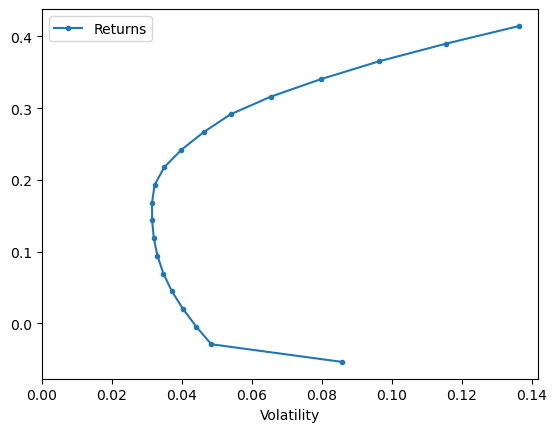

In [6]:
rf_rate = .1

In [7]:
w_msr = msr(rf_rate, er, cov)
w_msr

array([5.87725504e-16, 0.00000000e+00, 3.41793120e-15, 0.00000000e+00,
       4.25144035e-15, 0.00000000e+00, 0.00000000e+00, 4.55961441e-01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.33810808e-01, 0.00000000e+00, 9.56967016e-15,
       0.00000000e+00, 1.38704162e-01, 7.98190308e-15, 8.94092055e-02,
       2.31396517e-15, 0.00000000e+00, 1.55177174e-02, 1.49361063e-15,
       0.00000000e+00, 1.56867014e-15, 6.65966659e-02, 0.00000000e+00,
       3.42587153e-15, 0.00000000e+00])

In [8]:
r_mst = rk.portfolio_return(w_msr, er)
vol_msr = rk.portfolio_vol(w_msr, cov)

In [9]:
cml_x = [0, vol_msr]
cml_y = [rf_rate, r_mst]

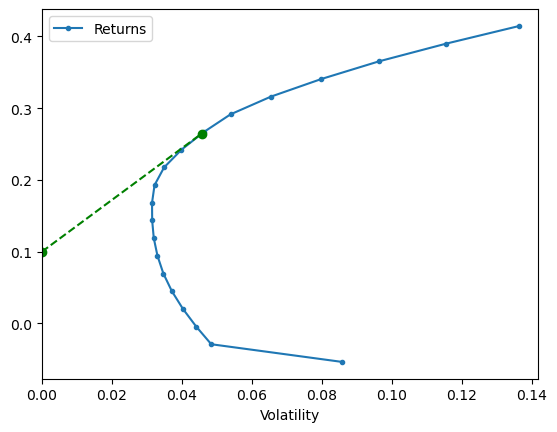

In [11]:
ax = rk.plot_ef(20, er, cov)
ax.set_xlim(left = 0)
ax.plot(cml_x, cml_y, color = 'green', marker = 'o', linestyle = '--')

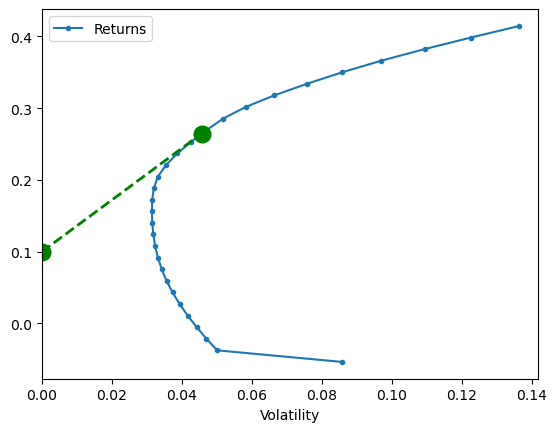

In [14]:
rk.plot_ef(30, er, cov, show_cml = True, riskfree_rate = .1)